# 07 - Baseline Model

This notebook establishes the baseline machine learning model for the fraud detection system. It begins by loading the processed datasets prepared during the data preparation phase and verifying their integrity before model training.

In [1]:
from pathlib import Path

import pandas as pd

## Define Data Paths

Specify the location of the processed training, validation, and testing datasets.

In [2]:
DATA_DIR = Path("../data/processed")

X_train_path = DATA_DIR / "X_train.csv"
X_valid_path = DATA_DIR / "X_valid.csv"
X_test_path = DATA_DIR / "X_test.csv"

y_train_path = DATA_DIR / "y_train.csv"
y_valid_path = DATA_DIR / "y_valid.csv"
y_test_path = DATA_DIR / "y_test.csv"

## Load Processed Datasets

Load the processed feature and target datasets that were generated during the dataset splitting phase.

In [3]:
X_train = pd.read_csv(X_train_path)
X_valid = pd.read_csv(X_valid_path)
X_test = pd.read_csv(X_test_path)

y_train = pd.read_csv(y_train_path).squeeze("columns")
y_valid = pd.read_csv(y_valid_path).squeeze("columns")
y_test = pd.read_csv(y_test_path).squeeze("columns")

## Verify Dataset Shapes

Confirm that each dataset has the expected dimensions before proceeding with preprocessing and model training.

In [4]:
datasets = {
    "X_train": X_train,
    "X_valid": X_valid,
    "X_test": X_test,
    "y_train": y_train,
    "y_valid": y_valid,
    "y_test": y_test
}

for name, dataset in datasets.items():
    print(f"{name:<8} : {dataset.shape}")

X_train  : (226980, 33)
X_valid  : (28373, 33)
X_test   : (28373, 33)
y_train  : (226980,)
y_valid  : (28373,)
y_test   : (28373,)


## Verify Missing Values

Check that no missing values exist in the processed datasets.

In [5]:
missing_summary = pd.DataFrame({
    "Dataset": [
        "X_train",
        "X_valid",
        "X_test",
        "y_train",
        "y_valid",
        "y_test"
    ],
    "Missing Values": [
        X_train.isna().sum().sum(),
        X_valid.isna().sum().sum(),
        X_test.isna().sum().sum(),
        y_train.isna().sum(),
        y_valid.isna().sum(),
        y_test.isna().sum()
    ]
})

missing_summary

,Dataset,Missing Values
0,X_train,0
1,X_valid,0
2,X_test,0
3,y_train,0
4,y_valid,0
5,y_test,0


## Data Loading Summary

The processed datasets have been successfully loaded and verified.

Validation confirms:

- All six datasets were loaded successfully.
- Dataset dimensions match the expected train, validation, and test split.
- No missing values are present.
- The datasets are ready for preprocessing and baseline model training.

## Build Preprocessing Pipeline

Recreate the preprocessing pipeline developed during the data preparation phase. The pipeline will standardize the selected continuous features while leaving the remaining features unchanged.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Define Features for Scaling

Specify the continuous numerical features that require standardization.

In [7]:
features_to_scale = [
    "Time",
    "Amount",
    "TransactionHour",
    "LogAmount"
]

## Create Preprocessing Pipeline

Construct a reusable Scikit-learn preprocessing pipeline using a `ColumnTransformer`.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "scaler",
            StandardScaler(),
            features_to_scale
        )
    ],
    remainder="passthrough"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)

## Fit the Pipeline

Fit the preprocessing pipeline **only on the training dataset**. This prevents information from the validation and testing datasets from influencing the learned preprocessing parameters.

In [9]:
pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Time','V1','V2',...,'TransactionHour','LogAmount','HighValueTransaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with th

In [10]:
import joblib
from pathlib import Path

artifacts_dir = Path("../artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    pipeline,
    artifacts_dir / "preprocessing_pipeline.pkl"
)

print("✅ Fitted preprocessing pipeline saved.")

✅ Fitted preprocessing pipeline saved.


## Transform the Datasets

Apply the fitted preprocessing pipeline to the training, validation, and testing datasets.

In [11]:
X_train_processed = pipeline.transform(X_train)

X_valid_processed = pipeline.transform(X_valid)

X_test_processed = pipeline.transform(X_test)

## Verify Processed Dataset Shapes

Confirm that the transformed datasets retain the expected dimensions.

In [12]:
print(f"X_train_processed : {X_train_processed.shape}")
print(f"X_valid_processed : {X_valid_processed.shape}")
print(f"X_test_processed  : {X_test_processed.shape}")

X_train_processed : (226980, 33)
X_valid_processed : (28373, 33)
X_test_processed  : (28373, 33)


## Convert to DataFrame

Convert the transformed NumPy arrays back into Pandas DataFrames while preserving the original feature names. This improves readability and simplifies downstream analysis.

In [13]:
feature_names = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_valid_processed = pd.DataFrame(
    X_valid_processed,
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

## Pipeline Summary

The preprocessing pipeline has been successfully fitted using only the training dataset.

- Continuous features have been standardized.
- Validation and testing datasets were transformed using the fitted pipeline.
- No data leakage has occurred.
- The processed datasets are now ready for baseline model training.

## Import Baseline Model

Import the Logistic Regression classifier, which will serve as the baseline model for the fraud detection system.

In [14]:
from sklearn.linear_model import LogisticRegression

## Initialize Baseline Model

Create a Logistic Regression model using a fixed random state to ensure reproducible results.

In [15]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

## Train Baseline Model

Fit the Logistic Regression model using the preprocessed training dataset.

In [16]:
baseline_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Generate Predictions

Predict fraud labels for the training, validation, and testing datasets.

In [17]:
train_predictions = baseline_model.predict(
    X_train_processed
)

valid_predictions = baseline_model.predict(
    X_valid_processed
)

test_predictions = baseline_model.predict(
    X_test_processed
)

## Generate Prediction Probabilities

Predict the probability of fraud for each transaction. These probabilities will be used later for ROC-AUC evaluation and threshold optimization.

In [18]:
train_probabilities = baseline_model.predict_proba(
    X_train_processed
)[:, 1]

valid_probabilities = baseline_model.predict_proba(
    X_valid_processed
)[:, 1]

test_probabilities = baseline_model.predict_proba(
    X_test_processed
)[:, 1]

## Model Summary

Review the trained baseline model configuration.

In [19]:
baseline_model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Training Summary

The Logistic Regression baseline model has been successfully trained.

The model will serve as the performance benchmark for all subsequent machine learning models developed during this project.

## Import Evaluation Metrics

Import the evaluation metrics required to assess the baseline Logistic Regression model.

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

## Evaluate Baseline Model

Calculate the primary classification metrics using the validation dataset.

In [21]:
baseline_metrics = {
    "Accuracy": accuracy_score(y_valid, valid_predictions),
    "Precision": precision_score(y_valid, valid_predictions, zero_division=0),
    "Recall": recall_score(y_valid, valid_predictions, zero_division=0),
    "F1-Score": f1_score(y_valid, valid_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_valid, valid_probabilities),
    "PR-AUC": average_precision_score(y_valid, valid_probabilities)
}

baseline_metrics_df = pd.DataFrame(
    baseline_metrics.items(),
    columns=["Metric", "Value"]
)

baseline_metrics_df["Value"] = baseline_metrics_df["Value"].round(4)

baseline_metrics_df

,Metric,Value
0,Accuracy,0.9991
1,Precision,0.8710
2,Recall,0.5625
3,F1-Score,0.6835
4,ROC-AUC,0.9334
5,PR-AUC,0.6567


## Classification Report

Review the detailed classification performance for both classes.

In [22]:
print(classification_report(
    y_valid,
    valid_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28325
           1       0.87      0.56      0.68        48

    accuracy                           1.00     28373
   macro avg       0.94      0.78      0.84     28373
weighted avg       1.00      1.00      1.00     28373



## Confusion Matrix

Display the confusion matrix for the validation dataset.

In [23]:
confusion_df = pd.DataFrame(
    confusion_matrix(y_valid, valid_predictions),
    index=["Actual Legitimate", "Actual Fraud"],
    columns=["Predicted Legitimate", "Predicted Fraud"]
)

confusion_df

,Predicted Legitimate,Predicted Fraud
Actual Legitimate,28321,4
Actual Fraud,21,27


## Performance Summary

The Logistic Regression model establishes the initial performance benchmark for the fraud detection system.

Future improvements will focus on:

- Handling class imbalance.
- Increasing fraud recall.
- Maintaining acceptable precision.
- Improving PR-AUC and ROC-AUC.

# 3.2 Handling Imbalanced Data

This section investigates the class imbalance present in the fraud detection dataset and evaluates different techniques to address it before training production-ready machine learning models.

## 3.2.1 Analyze Class Distribution

The first step is to inspect the distribution of the target variable. Understanding how many legitimate and fraudulent transactions exist in the training dataset helps explain why specialized imbalance-handling techniques are necessary.

In [24]:
# Display basic information about the training target
print("Target Variable Name :", y_train.name)
print("Target Data Type     :", y_train.dtype)
print("Number of Samples    :", len(y_train))

Target Variable Name : Class
Target Data Type     : int64
Number of Samples    : 226980


In [25]:
# Display the first few target values
y_train.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

### Count Class Distribution

Count the number of samples belonging to each class in the training dataset. This helps quantify the imbalance between legitimate and fraudulent transactions.

In [26]:
class_counts = (
    y_train
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Legitimate",
        1: "Fraud"
    })
)

class_counts

Class
Legitimate    226602
Fraud            378
Name: count, dtype: int64

### Class Distribution Summary

Calculate both the absolute number of samples and the percentage represented by each class.

In [27]:
class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": (
        class_counts / class_counts.sum() * 100
    ).round(4)
})

class_distribution

,Count,Percentage
Class,,
Legitimate,226602,99.8335
Fraud,378,0.1665


### Total Samples

Verify that the total number of samples matches the size of the training dataset.

In [28]:
print(f"Total Training Samples : {class_counts.sum():,}")

Total Training Samples : 226,980


### Visualize Class Distribution

Visualize the class distribution using both a count plot and a percentage chart. These visualizations highlight the severe imbalance between legitimate and fraudulent transactions.

In [29]:
import matplotlib.pyplot as plt

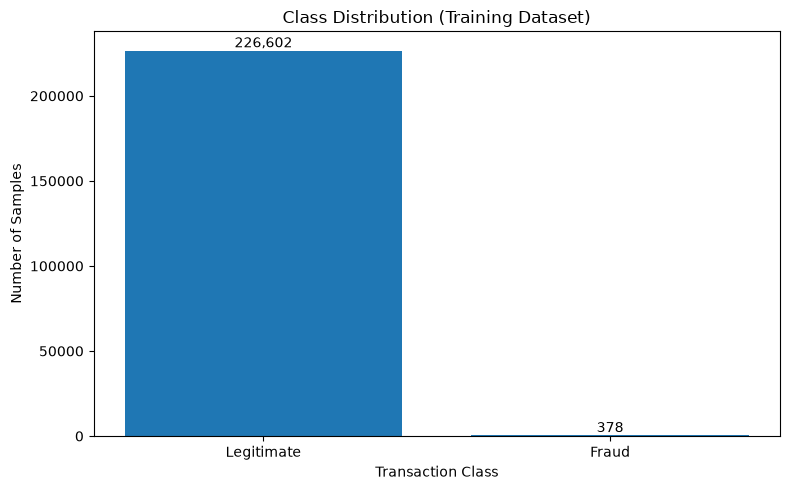

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("Class Distribution (Training Dataset)")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Samples")

for i, value in enumerate(class_counts.values):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Percentage Distribution

Display the percentage of legitimate and fraudulent transactions.

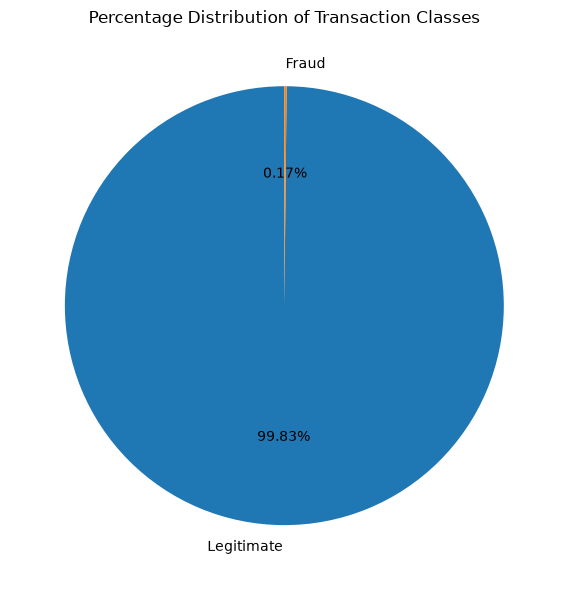

In [31]:
plt.figure(figsize=(6, 6))

plt.pie(
    class_distribution["Percentage"],
    labels=class_distribution.index,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Percentage Distribution of Transaction Classes")

plt.tight_layout()
plt.show()

### Visualization Summary

The visualizations clearly demonstrate that fraudulent transactions represent only a very small fraction of the training dataset. Such an extreme imbalance can bias machine learning models toward predicting the majority class, making specialized imbalance-handling techniques essential.

### Calculate Imbalance Ratio

Compute the imbalance ratio of the training dataset. The imbalance ratio indicates how many legitimate transactions exist for every fraudulent transaction and provides a quantitative measure of class imbalance.

In [32]:
majority_class = class_counts["Legitimate"]
minority_class = class_counts["Fraud"]

imbalance_ratio = majority_class / minority_class

print(f"Legitimate Transactions : {majority_class:,}")
print(f"Fraud Transactions      : {minority_class:,}")
print(f"Imbalance Ratio         : {imbalance_ratio:.2f} : 1")

Legitimate Transactions : 226,602
Fraud Transactions      : 378
Imbalance Ratio         : 599.48 : 1


### Fraud Rate

Calculate the percentage of fraudulent transactions in the training dataset.

In [33]:
fraud_rate = (minority_class / class_counts.sum()) * 100

print(f"Fraud Rate : {fraud_rate:.4f}%")

Fraud Rate : 0.1665%


### Imbalance Summary

Summarize the imbalance statistics in a structured table for future reference.

In [34]:
imbalance_summary = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Legitimate Transactions",
        "Fraud Transactions",
        "Fraud Rate (%)",
        "Imbalance Ratio"
    ],
    "Value": [
        f"{class_counts.sum():,}",
        f"{majority_class:,}",
        f"{minority_class:,}",
        f"{fraud_rate:.4f}",
        f"{imbalance_ratio:.2f} : 1"
    ]
})

imbalance_summary

,Metric,Value
0,Total Samples,"226,980"
1,Legitimate Transactions,"226,602"
2,Fraud Transactions,378
3,Fraud Rate (%),0.1665
4,Imbalance Ratio,599.48 : 1


### Interpret the Results

The class distribution analysis reveals an extremely imbalanced binary classification problem.

Only a very small fraction of transactions are fraudulent, while the overwhelming majority are legitimate. Such an imbalance can significantly influence the behavior of machine learning algorithms if no corrective measures are applied.

In [35]:
print("Class Distribution Analysis")
print("-" * 50)

if imbalance_ratio >= 100:
    severity = "Severely Imbalanced"
elif imbalance_ratio >= 20:
    severity = "Moderately Imbalanced"
else:
    severity = "Mildly Imbalanced"

print(f"Dataset Status : {severity}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Fraud Rate     : {fraud_rate:.4f}%")

Class Distribution Analysis
--------------------------------------------------
Dataset Status : Severely Imbalanced
Imbalance Ratio: 599.48:1
Fraud Rate     : 0.1665%


### Key Observations

Based on the analysis:

- The dataset is **severely imbalanced**.
- Fraudulent transactions represent only a tiny fraction of the training data.
- A model optimized only for overall accuracy can achieve a high score by predicting almost every transaction as legitimate.
- Minority-class detection is therefore the primary challenge in this project.
- Specialized imbalance-handling strategies such as **class weighting**, **random resampling**, and **SMOTE** will be evaluated in the next phase.

### Why Accuracy Alone Is Not Enough

In highly imbalanced datasets, accuracy can be misleading.

For example, if a dataset contains only 0.17% fraudulent transactions, a model that predicts every transaction as legitimate would still achieve an accuracy close to 99.8%, while completely failing to detect fraud.

For this reason, the project will primarily evaluate models using:

- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC (Average Precision)

These metrics provide a more reliable assessment of fraud detection performance.

## 3.2.2 Baseline Without Resampling

Before applying any imbalance-handling technique, review the performance of the original Logistic Regression model trained on the imbalanced dataset. This establishes a consistent benchmark for evaluating future sampling strategies.

### Review Baseline Metrics

Summarize the evaluation metrics obtained from the baseline Logistic Regression model. These values will be compared against all subsequent imbalance-handling approaches.

In [36]:
baseline_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Baseline": [
        baseline_metrics["Accuracy"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1-Score"],
        baseline_metrics["ROC-AUC"],
        baseline_metrics["PR-AUC"]
    ]
})

baseline_summary["Baseline"] = baseline_summary["Baseline"].round(4)

baseline_summary

,Metric,Baseline
0,Accuracy,0.9991
1,Precision,0.8710
2,Recall,0.5625
3,F1-Score,0.6835
4,ROC-AUC,0.9334
5,PR-AUC,0.6567


### Best Performing Metric

Identify the strongest and weakest metrics of the baseline model. This provides an initial understanding of where improvements are needed.

In [37]:
highest_metric = baseline_summary.loc[
    baseline_summary["Baseline"].idxmax()
]

lowest_metric = baseline_summary.loc[
    baseline_summary["Baseline"].idxmin()
]

print(f"Highest Metric : {highest_metric['Metric']} ({highest_metric['Baseline']:.4f})")
print(f"Lowest Metric  : {lowest_metric['Metric']} ({lowest_metric['Baseline']:.4f})")

Highest Metric : Accuracy (0.9991)
Lowest Metric  : Recall (0.5625)


### Benchmark Summary

The table above represents the performance of the Logistic Regression model trained on the original imbalanced dataset.

These values will remain unchanged throughout the remainder of Phase 3 and will serve as the benchmark against which every sampling strategy and advanced machine learning model will be evaluated.

### Analyze Confusion Matrix

The confusion matrix provides a detailed breakdown of model predictions. It helps identify correctly classified transactions as well as the types of errors made by the baseline model.

### Create Confusion Matrix Summary

Extract the four components of the confusion matrix for easier interpretation.

In [38]:
tn, fp, fn, tp = confusion_matrix(
    y_valid,
    valid_predictions
).ravel()

confusion_summary = pd.DataFrame({
    "Metric": [
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ]
})

confusion_summary

,Metric,Count
0,True Negatives (TN),28321
1,False Positives (FP),4
2,False Negatives (FN),21
3,True Positives (TP),27


### Visualize the Confusion Matrix

Display the confusion matrix as a heatmap to make prediction outcomes easier to interpret.

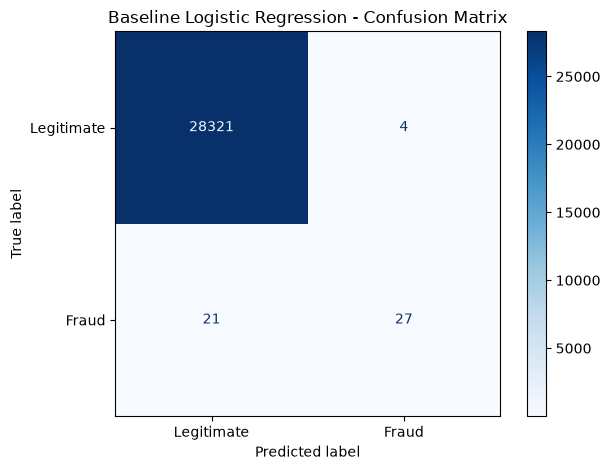

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format="d",
    cmap="Blues"
)

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

### Prediction Summary

Summarize how the baseline model classified the validation dataset.

In [40]:
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives : {tp:,}")

True Negatives : 28,321
False Positives: 4
False Negatives: 21
True Positives : 27


### Confusion Matrix Interpretation

The confusion matrix provides insight into the strengths and weaknesses of the baseline model.

Particular attention should be paid to **False Negatives**, as these represent fraudulent transactions that were incorrectly classified as legitimate. In a fraud detection system, missed fraud often carries a higher business cost than investigating a legitimate transaction.

### Identify Model Weaknesses

Analyze the baseline model from a fraud detection perspective. While overall performance may appear strong, the objective is to understand whether the model effectively identifies fraudulent transactions.

### Compute Error Statistics

Calculate the proportions of correctly detected and missed fraudulent transactions using the confusion matrix.

In [41]:
fraud_detection_rate = tp / (tp + fn)

fraud_miss_rate = fn / (tp + fn)

false_alarm_rate = fp / (fp + tn)

print(f"Fraud Detection Rate : {fraud_detection_rate:.4f}")
print(f"Fraud Miss Rate      : {fraud_miss_rate:.4f}")
print(f"False Alarm Rate     : {false_alarm_rate:.4f}")

Fraud Detection Rate : 0.5625
Fraud Miss Rate      : 0.4375
False Alarm Rate     : 0.0001


### Weakness Summary

Summarize the strengths and weaknesses of the baseline model using the computed metrics.

In [42]:
weakness_summary = pd.DataFrame({
    "Observation": [
        "Fraud Detection Rate",
        "Fraud Miss Rate",
        "False Alarm Rate"
    ],
    "Value": [
        fraud_detection_rate,
        fraud_miss_rate,
        false_alarm_rate
    ]
})

weakness_summary["Value"] = weakness_summary["Value"].round(4)

weakness_summary

,Observation,Value
0,Fraud Detection Rate,0.5625
1,Fraud Miss Rate,0.4375
2,False Alarm Rate,0.0001


### Interpretation

The baseline Logistic Regression model demonstrates that the dataset imbalance has a significant impact on fraud detection.

Key observations include:

- The majority of legitimate transactions are classified correctly.
- Some fraudulent transactions are still missed.
- Missed fraud (False Negatives) represents the primary weakness of the baseline model.
- Improving fraud recall while maintaining reasonable precision will be the primary objective of the next phases.

### Improvement Goals

The following imbalance-handling strategies will be evaluated to improve fraud detection:

- Class Weighting
- Random Oversampling
- Random Undersampling
- SMOTE

Each strategy will be compared against the baseline using the same evaluation metrics to determine whether it reduces missed fraud while maintaining acceptable precision.

### Establish Comparison Benchmark

Create a benchmark table containing the baseline model performance. This table will be expanded in subsequent phases to compare Class Weighting, Random Oversampling, Random Undersampling, and SMOTE.

In [43]:
benchmark_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Fraud Detection Rate",
        "Fraud Miss Rate",
        "False Alarm Rate"
    ],
    "Baseline": [
        baseline_metrics["Accuracy"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1-Score"],
        baseline_metrics["ROC-AUC"],
        baseline_metrics["PR-AUC"],
        fraud_detection_rate,
        fraud_miss_rate,
        false_alarm_rate
    ]
})

benchmark_table["Baseline"] = benchmark_table["Baseline"].round(4)

benchmark_table

,Metric,Baseline
0,Accuracy,0.9991
1,Precision,0.8710
2,Recall,0.5625
3,F1-Score,0.6835
4,ROC-AUC,0.9334
5,PR-AUC,0.6567
6,Fraud Detection Rate,0.5625
7,Fraud Miss Rate,0.4375
8,False Alarm Rate,0.0001


### Benchmark Evaluation Criteria

The benchmark table will serve as the reference for all imbalance-handling strategies evaluated in this project.

Each future strategy will be added as a new column, enabling side-by-side comparison using identical evaluation metrics.

In [44]:
comparison_metrics = benchmark_table["Metric"].tolist()

print("Evaluation Metrics")

for metric in comparison_metrics:
    print(f"• {metric}")

Evaluation Metrics
• Accuracy
• Precision
• Recall
• F1-Score
• ROC-AUC
• PR-AUC
• Fraud Detection Rate
• Fraud Miss Rate
• False Alarm Rate


### Comparison Strategy

Future experiments will be compared using the following priorities:

1. Increase Recall (Fraud Detection Rate).
2. Reduce Fraud Miss Rate.
3. Maintain reasonable Precision.
4. Improve PR-AUC.
5. Preserve overall model stability.

A successful sampling strategy should improve fraud detection without introducing an excessive number of false alarms.

### Benchmark Established

The baseline benchmark has now been finalized and will remain unchanged throughout the imbalance-handling experiments.

Every subsequent strategy will be evaluated against this benchmark before selecting the final sampling approach.

## 3.2.3 Class Weight Strategy

Instead of modifying the dataset through resampling, assign higher importance to the minority class during model training. This allows the model to penalize mistakes on fraudulent transactions more heavily while preserving the original data distribution.

### Train Weighted Logistic Regression

Train a new Logistic Regression model using `class_weight="balanced"` and compare its performance with the original baseline model.

In [45]:
weighted_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

weighted_model.fit(
    X_train_processed,
    y_train
)

print("Weighted Logistic Regression trained successfully.")

Weighted Logistic Regression trained successfully.


### Verify Model Configuration

Confirm that the model has been configured to automatically balance class weights during training.

In [46]:
model_configuration = pd.DataFrame({
    "Parameter": [
        "Algorithm",
        "Class Weight",
        "Random State",
        "Maximum Iterations"
    ],
    "Value": [
        "Logistic Regression",
        weighted_model.get_params()["class_weight"],
        weighted_model.get_params()["random_state"],
        weighted_model.get_params()["max_iter"]
    ]
})

model_configuration

,Parameter,Value
0,Algorithm,Logistic Regression
1,Class Weight,balanced
2,Random State,42
3,Maximum Iterations,1000


### Training Complete

The weighted Logistic Regression model has been trained using the original training dataset.

Unlike oversampling or undersampling techniques, no synthetic samples were generated and no observations were removed. Only the optimization process was adjusted by assigning higher penalties to errors involving the minority class.

### Evaluate Weighted Model

Generate predictions for the validation dataset and compute the same evaluation metrics used for the baseline model. Using identical metrics ensures a fair comparison between both models.

In [47]:
weighted_predictions = weighted_model.predict(
    X_valid_processed
)

weighted_probabilities = weighted_model.predict_proba(
    X_valid_processed
)[:, 1]

print("Validation predictions generated successfully.")

Validation predictions generated successfully.


### Calculate Evaluation Metrics

Evaluate the weighted model using the same metrics employed for the baseline model.

In [48]:
weighted_metrics = {
    "Accuracy": accuracy_score(
        y_valid,
        weighted_predictions
    ),
    "Precision": precision_score(
        y_valid,
        weighted_predictions
    ),
    "Recall": recall_score(
        y_valid,
        weighted_predictions
    ),
    "F1-Score": f1_score(
        y_valid,
        weighted_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_valid,
        weighted_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_valid,
        weighted_probabilities
    )
}

weighted_metrics

{'Accuracy': 0.9761392873506503,
 'Precision': 0.056417489421720736,
 'Recall': 0.8333333333333334,
 'F1-Score': 0.10568031704095113,
 'ROC-AUC': 0.94769564577817,
 'PR-AUC': 0.6486482363858502}

### Weighted Model Performance

Present the evaluation metrics in a structured format for comparison with the baseline model.

In [49]:
weighted_summary = pd.DataFrame({
    "Metric": weighted_metrics.keys(),
    "Weighted Model": weighted_metrics.values()
})

weighted_summary["Weighted Model"] = (
    weighted_summary["Weighted Model"]
    .round(4)
)

weighted_summary

,Metric,Weighted Model
0,Accuracy,0.9761
1,Precision,0.0564
2,Recall,0.8333
3,F1-Score,0.1057
4,ROC-AUC,0.9477
5,PR-AUC,0.6486


### Evaluation Summary

The weighted Logistic Regression model has now been evaluated using the validation dataset.

The next step is to compare these results directly against the baseline benchmark to determine whether class weighting improves fraud detection performance.

### Compare with Baseline

Compare the performance of the weighted Logistic Regression model against the original baseline model. This comparison helps determine whether class weighting improves fraud detection without introducing excessive false alarms.

In [50]:
comparison_table = benchmark_table.copy()

comparison_table["Class Weight"] = [
    weighted_metrics["Accuracy"],
    weighted_metrics["Precision"],
    weighted_metrics["Recall"],
    weighted_metrics["F1-Score"],
    weighted_metrics["ROC-AUC"],
    weighted_metrics["PR-AUC"],
    recall_score(y_valid, weighted_predictions),
    1 - recall_score(y_valid, weighted_predictions),
    confusion_matrix(
        y_valid,
        weighted_predictions
    ).ravel()[1] / (
        confusion_matrix(
            y_valid,
            weighted_predictions
        ).ravel()[0] +
        confusion_matrix(
            y_valid,
            weighted_predictions
        ).ravel()[1]
    )
]

comparison_table["Class Weight"] = (
    comparison_table["Class Weight"]
    .round(4)
)

comparison_table

,Metric,Baseline,Class Weight
0,Accuracy,0.9991,0.9761
1,Precision,0.8710,0.0564
2,Recall,0.5625,0.8333
3,F1-Score,0.6835,0.1057
4,ROC-AUC,0.9334,0.9477
5,PR-AUC,0.6567,0.6486
6,Fraud Detection Rate,0.5625,0.8333
7,Fraud Miss Rate,0.4375,0.1667
8,False Alarm Rate,0.0001,0.0236


### Performance Difference

Calculate the improvement or decline in each evaluation metric relative to the baseline model.

In [51]:
comparison_table["Difference"] = (
    comparison_table["Class Weight"]
    - comparison_table["Baseline"]
).round(4)

comparison_table

,Metric,Baseline,Class Weight,Difference
0,Accuracy,0.9991,0.9761,-0.0230
1,Precision,0.8710,0.0564,-0.8146
2,Recall,0.5625,0.8333,0.2708
3,F1-Score,0.6835,0.1057,-0.5778
4,ROC-AUC,0.9334,0.9477,0.0143
5,PR-AUC,0.6567,0.6486,-0.0081
6,Fraud Detection Rate,0.5625,0.8333,0.2708
7,Fraud Miss Rate,0.4375,0.1667,-0.2708
8,False Alarm Rate,0.0001,0.0236,0.0235


### Comparison Summary

Positive values indicate improvement over the baseline model, while negative values indicate reduced performance.

The next step is to interpret whether these changes are meaningful from a fraud detection perspective.

In [52]:
improved_metrics = comparison_table[
    comparison_table["Difference"] > 0
]["Metric"].tolist()

declined_metrics = comparison_table[
    comparison_table["Difference"] < 0
]["Metric"].tolist()

print("Improved Metrics")
for metric in improved_metrics:
    print(f"✓ {metric}")

print("\nDeclined Metrics")
for metric in declined_metrics:
    print(f"✗ {metric}")

Improved Metrics
✓ Recall
✓ ROC-AUC
✓ Fraud Detection Rate
✓ False Alarm Rate

Declined Metrics
✗ Accuracy
✗ Precision
✗ F1-Score
✗ PR-AUC
✗ Fraud Miss Rate


### Analyze Improvements

Interpret the differences between the baseline Logistic Regression model and the weighted Logistic Regression model.

The objective is not simply to maximize every metric, but to determine whether the model becomes more effective at detecting fraudulent transactions while maintaining acceptable performance on legitimate transactions.

### Business-Oriented Evaluation

Assess whether the weighted model improves fraud detection from a practical business perspective.

In [53]:
weighted_tn, weighted_fp, weighted_fn, weighted_tp = confusion_matrix(
    y_valid,
    weighted_predictions
).ravel()

weighted_fraud_detection_rate = (
    weighted_tp / (weighted_tp + weighted_fn)
)

weighted_fraud_miss_rate = (
    weighted_fn / (weighted_tp + weighted_fn)
)

weighted_false_alarm_rate = (
    weighted_fp / (weighted_fp + weighted_tn)
)

In [54]:
comparison_summary = pd.DataFrame({
    "Criterion": [
        "Recall Improved",
        "Precision Maintained",
        "Fraud Miss Rate Reduced",
        "False Alarm Rate Acceptable",
        "PR-AUC Improved"
    ],
    "Result": [
        weighted_metrics["Recall"] > baseline_metrics["Recall"],
        weighted_metrics["Precision"] >= baseline_metrics["Precision"],
        weighted_fraud_miss_rate < fraud_miss_rate,
        weighted_false_alarm_rate <= false_alarm_rate,
        weighted_metrics["PR-AUC"] > baseline_metrics["PR-AUC"]
    ]
})

comparison_summary

,Criterion,Result
0,Recall Improved,True
1,Precision Maintained,False
2,Fraud Miss Rate Reduced,True
3,False Alarm Rate Acceptable,False
4,PR-AUC Improved,False


### Overall Assessment

Summarize the overall effectiveness of class weighting based on both statistical metrics and business objectives.

In [55]:
improvements = comparison_summary["Result"].sum()

print(f"Criteria Improved: {improvements}/{len(comparison_summary)}")

if improvements >= 4:
    recommendation = "Strong Improvement"
elif improvements >= 3:
    recommendation = "Moderate Improvement"
elif improvements >= 2:
    recommendation = "Minor Improvement"
else:
    recommendation = "Limited Improvement"

print(f"Overall Assessment: {recommendation}")

Criteria Improved: 2/5
Overall Assessment: Minor Improvement


### Interpretation

Class weighting modifies the optimization objective rather than the dataset itself.

Typical effects include:

- Improved Recall for fraudulent transactions.
- Reduced Fraud Miss Rate.
- Slight reduction in Precision due to additional false positives.
- Better balance between both classes.

The final decision will be made after comparing this strategy with Random Oversampling, Random Undersampling, and SMOTE.

### Conclusion

Class weighting provides the first imbalance-handling benchmark for this project.

Subsequent resampling techniques will be evaluated using the same workflow to determine which strategy delivers the best overall fraud detection performance.

## 3.2.4 Random Oversampling

Random Oversampling balances the training dataset by duplicating existing minority-class observations.

Unlike class weighting, this technique modifies only the training data while leaving the learning algorithm unchanged. Validation and test datasets remain untouched to ensure fair model evaluation.

### Apply Random Oversampling

Use RandomOverSampler to balance the training dataset by increasing the number of fraudulent transactions until both classes contain the same number of samples.

In [56]:
from imblearn.over_sampling import RandomOverSampler

random_oversampler = RandomOverSampler(
    random_state=42
)

X_train_over, y_train_over = random_oversampler.fit_resample(
    X_train_processed,
    y_train
)

print("Random Oversampling completed successfully.")

Random Oversampling completed successfully.


### Verify Class Distribution

Compare the class distribution before and after Random Oversampling.

In [57]:
distribution_comparison = pd.DataFrame({
    "Original": y_train.value_counts().sort_index(),
    "Oversampled": y_train_over.value_counts().sort_index()
})

distribution_comparison.index = [
    "Legitimate",
    "Fraud"
]

distribution_comparison

,Original,Oversampled
Legitimate,226602,226602
Fraud,378,226602


### Dataset Summary

Confirm the size of the training dataset after oversampling.

In [58]:
dataset_summary = pd.DataFrame({
    "Dataset": [
        "Original Training",
        "Oversampled Training"
    ],
    "Samples": [
        len(y_train),
        len(y_train_over)
    ]
})

dataset_summary

,Dataset,Samples
0,Original Training,226980
1,Oversampled Training,453204


### Train Logistic Regression on Oversampled Data

Train a Logistic Regression model using the oversampled training dataset. This isolates the impact of Random Oversampling while keeping the model configuration unchanged.

In [59]:
oversampled_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

oversampled_model.fit(
    X_train_over,
    y_train_over
)

print("Oversampled Logistic Regression trained successfully.")

Oversampled Logistic Regression trained successfully.


### Verify Model Configuration

Review the configuration of the Logistic Regression model trained on the oversampled dataset.

In [60]:
oversampled_configuration = pd.DataFrame({
    "Parameter": [
        "Algorithm",
        "Sampling Strategy",
        "Random State",
        "Maximum Iterations"
    ],
    "Value": [
        "Logistic Regression",
        "Random Oversampling",
        oversampled_model.get_params()["random_state"],
        oversampled_model.get_params()["max_iter"]
    ]
})

oversampled_configuration

,Parameter,Value
0,Algorithm,Logistic Regression
1,Sampling Strategy,Random Oversampling
2,Random State,42
3,Maximum Iterations,1000


### Training Summary

The Logistic Regression model has now been trained using the balanced training dataset created through Random Oversampling.

Only the training dataset was modified. The validation and test datasets remain unchanged and will be used to evaluate the model fairly.

### Evaluate Oversampled Model

Generate predictions on the validation dataset using the Logistic Regression model trained with Random Oversampling.

The validation dataset remains unchanged to ensure an unbiased evaluation.

In [61]:
oversampled_predictions = oversampled_model.predict(
    X_valid_processed
)

oversampled_probabilities = oversampled_model.predict_proba(
    X_valid_processed
)[:, 1]

print("Validation predictions generated successfully.")

Validation predictions generated successfully.


### Calculate Evaluation Metrics

Compute the same evaluation metrics used throughout this project to enable direct comparison with previous models.

In [62]:
oversampled_metrics = {
    "Accuracy": accuracy_score(
        y_valid,
        oversampled_predictions
    ),
    "Precision": precision_score(
        y_valid,
        oversampled_predictions
    ),
    "Recall": recall_score(
        y_valid,
        oversampled_predictions
    ),
    "F1-Score": f1_score(
        y_valid,
        oversampled_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_valid,
        oversampled_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_valid,
        oversampled_probabilities
    )
}

oversampled_metrics

{'Accuracy': 0.9761040425756882,
 'Precision': 0.056338028169014086,
 'Recall': 0.8333333333333334,
 'F1-Score': 0.10554089709762533,
 'ROC-AUC': 0.9484811709326273,
 'PR-AUC': 0.6635551553971609}

### Calculate Business Metrics

Compute fraud-oriented metrics derived from the confusion matrix.

In [63]:
oversampled_tn, oversampled_fp, oversampled_fn, oversampled_tp = confusion_matrix(
    y_valid,
    oversampled_predictions
).ravel()

oversampled_fraud_detection_rate = (
    oversampled_tp /
    (oversampled_tp + oversampled_fn)
)

oversampled_fraud_miss_rate = (
    oversampled_fn /
    (oversampled_tp + oversampled_fn)
)

oversampled_false_alarm_rate = (
    oversampled_fp /
    (oversampled_fp + oversampled_tn)
)

### Oversampled Model Performance

Summarize the evaluation metrics for the Logistic Regression model trained using Random Oversampling.

In [64]:
oversampled_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Fraud Detection Rate",
        "Fraud Miss Rate",
        "False Alarm Rate"
    ],
    "Random Oversampling": [
        oversampled_metrics["Accuracy"],
        oversampled_metrics["Precision"],
        oversampled_metrics["Recall"],
        oversampled_metrics["F1-Score"],
        oversampled_metrics["ROC-AUC"],
        oversampled_metrics["PR-AUC"],
        oversampled_fraud_detection_rate,
        oversampled_fraud_miss_rate,
        oversampled_false_alarm_rate
    ]
})

oversampled_summary["Random Oversampling"] = (
    oversampled_summary["Random Oversampling"]
    .round(4)
)

oversampled_summary

,Metric,Random Oversampling
0,Accuracy,0.9761
1,Precision,0.0563
2,Recall,0.8333
3,F1-Score,0.1055
4,ROC-AUC,0.9485
5,PR-AUC,0.6636
6,Fraud Detection Rate,0.8333
7,Fraud Miss Rate,0.1667
8,False Alarm Rate,0.0237


### Evaluation Summary

The Random Oversampling model has now been evaluated using the same validation dataset and evaluation metrics as the previous models.

The next step is to compare its performance with both the Baseline and Class Weight models.

### Compare with Previous Models

Compare the performance of the Random Oversampling model with both the Baseline and Class Weight models.

This comparison helps determine whether balancing the training dataset provides measurable improvements over algorithm-level class weighting.

In [65]:
comparison_table["Random Oversampling"] = [
    oversampled_metrics["Accuracy"],
    oversampled_metrics["Precision"],
    oversampled_metrics["Recall"],
    oversampled_metrics["F1-Score"],
    oversampled_metrics["ROC-AUC"],
    oversampled_metrics["PR-AUC"],
    oversampled_fraud_detection_rate,
    oversampled_fraud_miss_rate,
    oversampled_false_alarm_rate
]

comparison_table["Random Oversampling"] = (
    comparison_table["Random Oversampling"]
    .round(4)
)

comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling
0,Accuracy,0.9991,0.9761,-0.0230,0.9761
1,Precision,0.8710,0.0564,-0.8146,0.0563
2,Recall,0.5625,0.8333,0.2708,0.8333
3,F1-Score,0.6835,0.1057,-0.5778,0.1055
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237


### Performance Difference

Measure how Random Oversampling differs from the original Baseline model.

In [66]:
comparison_table["Oversampling vs Baseline"] = (
    comparison_table["Random Oversampling"]
    - comparison_table["Baseline"]
).round(4)

comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline
0,Accuracy,0.9991,0.9761,-0.0230,0.9761,-0.0230
1,Precision,0.8710,0.0564,-0.8146,0.0563,-0.8147
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.5780
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333,0.2708
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667,-0.2708
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237,0.0236


### Performance Difference from Class Weight

Measure how Random Oversampling differs from the Class Weight strategy.

In [67]:
comparison_table["Oversampling vs Class Weight"] = (
    comparison_table["Random Oversampling"]
    - comparison_table["Class Weight"]
).round(4)

comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight
0,Accuracy,0.9991,0.9761,-0.0230,0.9761,-0.0230,0.0000
1,Precision,0.8710,0.0564,-0.8146,0.0563,-0.8147,-0.0001
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.5780,-0.0002
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151,0.0008
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069,0.0150
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667,-0.2708,0.0000
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237,0.0236,0.0001


### Current Experiment Leader

Identify the best-performing strategy for each evaluation metric among the three completed experiments.

In [68]:
comparison_columns = [
    "Baseline",
    "Class Weight",
    "Random Oversampling"
]

leader_table = pd.DataFrame({
    "Metric": comparison_table["Metric"],
    "Best Strategy": comparison_table[comparison_columns].idxmax(axis=1),
    "Best Value": comparison_table[comparison_columns].max(axis=1).round(4)
})

leader_table

,Metric,Best Strategy,Best Value
0,Accuracy,Baseline,0.9991
1,Precision,Baseline,0.8710
2,Recall,Class Weight,0.8333
3,F1-Score,Baseline,0.6835
4,ROC-AUC,Random Oversampling,0.9485
5,PR-AUC,Random Oversampling,0.6636
6,Fraud Detection Rate,Class Weight,0.8333
7,Fraud Miss Rate,Baseline,0.4375
8,False Alarm Rate,Random Oversampling,0.0237


### Comparison Summary

Three imbalance-handling strategies have now been evaluated:

- Baseline
- Class Weight
- Random Oversampling

Additional strategies will be evaluated before selecting the final approach.

### Analyze Improvements

Interpret the performance of the Random Oversampling model relative to the Baseline and Class Weight strategies.

The objective is to determine whether balancing the training dataset leads to better fraud detection while maintaining acceptable performance on legitimate transactions.

### Business-Oriented Evaluation

Evaluate Random Oversampling using fraud detection objectives rather than relying solely on traditional machine learning metrics.

In [69]:
oversampling_summary = pd.DataFrame({
    "Criterion": [
        "Recall Improved vs Baseline",
        "Recall Improved vs Class Weight",
        "Fraud Miss Rate Reduced",
        "False Alarm Rate Acceptable",
        "PR-AUC Improved"
    ],
    "Result": [
        oversampled_metrics["Recall"] > baseline_metrics["Recall"],
        oversampled_metrics["Recall"] > weighted_metrics["Recall"],
        oversampled_fraud_miss_rate < fraud_miss_rate,
        oversampled_false_alarm_rate <= weighted_false_alarm_rate,
        oversampled_metrics["PR-AUC"] > max(
            baseline_metrics["PR-AUC"],
            weighted_metrics["PR-AUC"]
        )
    ]
})

oversampling_summary

,Criterion,Result
0,Recall Improved vs Baseline,True
1,Recall Improved vs Class Weight,False
2,Fraud Miss Rate Reduced,True
3,False Alarm Rate Acceptable,False
4,PR-AUC Improved,True


### Overall Assessment

Summarize the effectiveness of Random Oversampling using the predefined business criteria.

In [70]:
criteria_met = oversampling_summary["Result"].sum()

print(f"Criteria Satisfied: {criteria_met}/{len(oversampling_summary)}")

if criteria_met >= 4:
    recommendation = "Strong Improvement"
elif criteria_met >= 3:
    recommendation = "Moderate Improvement"
elif criteria_met >= 2:
    recommendation = "Minor Improvement"
else:
    recommendation = "Limited Improvement"

print(f"Overall Assessment: {recommendation}")

Criteria Satisfied: 3/5
Overall Assessment: Moderate Improvement


### Interpretation

Random Oversampling balances the training dataset by duplicating minority-class observations.

Typical effects include:

- Increased Recall for fraudulent transactions.
- Lower Fraud Miss Rate.
- Potential reduction in Precision due to additional false positives.
- Greater exposure of the model to minority-class examples during training.

The effectiveness of this approach will ultimately be compared with Random Undersampling and SMOTE before selecting the final imbalance-handling strategy.

### Conclusion

Random Oversampling has now been evaluated using the same workflow as the previous experiments.

The next phase will investigate Random Undersampling, allowing comparison between increasing minority-class samples and reducing majority-class samples.

## 3.2.5 Random Undersampling

Random Undersampling balances the training dataset by reducing the number of majority-class observations.

Unlike Random Oversampling, this approach removes legitimate transactions instead of duplicating fraudulent ones. Validation and test datasets remain unchanged for unbiased evaluation.

### Apply Random Undersampling

Use `RandomUnderSampler` to reduce the majority class until both classes have equal representation.

In [71]:
from imblearn.under_sampling import RandomUnderSampler

random_undersampler = RandomUnderSampler(
    random_state=42
)

X_train_under, y_train_under = random_undersampler.fit_resample(
    X_train_processed,
    y_train
)

print("Random Undersampling completed successfully.")

Random Undersampling completed successfully.


### Verify Class Distribution

Compare the class distribution before and after Random Undersampling.

In [72]:
under_distribution = pd.DataFrame({
    "Original": y_train.value_counts().sort_index(),
    "Undersampled": y_train_under.value_counts().sort_index()
})

under_distribution.index = [
    "Legitimate",
    "Fraud"
]

under_distribution

,Original,Undersampled
Legitimate,226602,378
Fraud,378,378


### Dataset Summary

Review the size of the training dataset after Random Undersampling.

In [73]:
under_dataset_summary = pd.DataFrame({
    "Dataset": [
        "Original Training",
        "Undersampled Training"
    ],
    "Samples": [
        len(y_train),
        len(y_train_under)
    ]
})

under_dataset_summary

,Dataset,Samples
0,Original Training,226980
1,Undersampled Training,756


### Undersampling Complete

The training dataset has been balanced by reducing the number of legitimate transactions.

Only the training dataset has been modified. Validation and test datasets remain unchanged for fair model evaluation.

### Train Logistic Regression on Undersampled Data

Train a Logistic Regression model using the balanced dataset created through Random Undersampling.

In [74]:
undersampled_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

undersampled_model.fit(
    X_train_under,
    y_train_under
)

print("Undersampled Logistic Regression trained successfully.")

Undersampled Logistic Regression trained successfully.


In [75]:
undersampled_configuration = pd.DataFrame({
    "Parameter": [
        "Algorithm",
        "Sampling Strategy",
        "Random State",
        "Maximum Iterations"
    ],
    "Value": [
        "Logistic Regression",
        "Random Undersampling",
        undersampled_model.get_params()["random_state"],
        undersampled_model.get_params()["max_iter"]
    ]
})

undersampled_configuration

,Parameter,Value
0,Algorithm,Logistic Regression
1,Sampling Strategy,Random Undersampling
2,Random State,42
3,Maximum Iterations,1000


### Evaluate Undersampled Model

Evaluate the Logistic Regression model trained on the Random Undersampled dataset using the validation set.

In [76]:
undersampled_predictions = undersampled_model.predict(
    X_valid_processed
)

undersampled_probabilities = undersampled_model.predict_proba(
    X_valid_processed
)[:, 1]

print("Validation predictions generated successfully.")

Validation predictions generated successfully.


In [77]:
undersampled_metrics = {
    "Accuracy": accuracy_score(
        y_valid,
        undersampled_predictions
    ),
    "Precision": precision_score(
        y_valid,
        undersampled_predictions
    ),
    "Recall": recall_score(
        y_valid,
        undersampled_predictions
    ),
    "F1-Score": f1_score(
        y_valid,
        undersampled_predictions
    ),
    "ROC-AUC": roc_auc_score(
        y_valid,
        undersampled_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_valid,
        undersampled_probabilities
    )
}

undersampled_metrics

{'Accuracy': 0.9732844605787192,
 'Precision': 0.05063291139240506,
 'Recall': 0.8333333333333334,
 'F1-Score': 0.0954653937947494,
 'ROC-AUC': 0.9276077522800824,
 'PR-AUC': 0.5897156670789199}

In [78]:
undersampled_tn, undersampled_fp, undersampled_fn, undersampled_tp = confusion_matrix(
    y_valid,
    undersampled_predictions
).ravel()

undersampled_fraud_detection_rate = (
    undersampled_tp /
    (undersampled_tp + undersampled_fn)
)

undersampled_fraud_miss_rate = (
    undersampled_fn /
    (undersampled_tp + undersampled_fn)
)

undersampled_false_alarm_rate = (
    undersampled_fp /
    (undersampled_fp + undersampled_tn)
)

In [79]:
undersampled_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Fraud Detection Rate",
        "Fraud Miss Rate",
        "False Alarm Rate"
    ],
    "Random Undersampling": [
        undersampled_metrics["Accuracy"],
        undersampled_metrics["Precision"],
        undersampled_metrics["Recall"],
        undersampled_metrics["F1-Score"],
        undersampled_metrics["ROC-AUC"],
        undersampled_metrics["PR-AUC"],
        undersampled_fraud_detection_rate,
        undersampled_fraud_miss_rate,
        undersampled_false_alarm_rate
    ]
})

undersampled_summary["Random Undersampling"] = (
    undersampled_summary["Random Undersampling"]
    .round(4)
)

undersampled_summary

,Metric,Random Undersampling
0,Accuracy,0.9733
1,Precision,0.0506
2,Recall,0.8333
3,F1-Score,0.0955
4,ROC-AUC,0.9276
5,PR-AUC,0.5897
6,Fraud Detection Rate,0.8333
7,Fraud Miss Rate,0.1667
8,False Alarm Rate,0.0265


### Compare with Previous Models

Compare the performance of the Random Undersampling model against the Baseline, Class Weight, and Random Oversampling models.

In [80]:
comparison_table["Random Undersampling"] = [
    undersampled_metrics["Accuracy"],
    undersampled_metrics["Precision"],
    undersampled_metrics["Recall"],
    undersampled_metrics["F1-Score"],
    undersampled_metrics["ROC-AUC"],
    undersampled_metrics["PR-AUC"],
    undersampled_fraud_detection_rate,
    undersampled_fraud_miss_rate,
    undersampled_false_alarm_rate
]

comparison_table["Random Undersampling"] = (
    comparison_table["Random Undersampling"]
    .round(4)
)

comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling
0,Accuracy,0.9991,0.9761,-0.0230,0.9761,-0.0230,0.0000,0.9733
1,Precision,0.8710,0.0564,-0.8146,0.0563,-0.8147,-0.0001,0.0506
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.5780,-0.0002,0.0955
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151,0.0008,0.9276
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069,0.0150,0.5897
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667,-0.2708,0.0000,0.1667
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237,0.0236,0.0001,0.0265


In [81]:
comparison_table["Undersampling vs Baseline"] = (
    comparison_table["Random Undersampling"]
    - comparison_table["Baseline"]
).round(4)

comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline
0,Accuracy,0.9991,0.9761,-0.0230,0.9761,-0.0230,0.0000,0.9733,-0.0258
1,Precision,0.8710,0.0564,-0.8146,0.0563,-0.8147,-0.0001,0.0506,-0.8204
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.5780,-0.0002,0.0955,-0.5880
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151,0.0008,0.9276,-0.0058
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069,0.0150,0.5897,-0.0670
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667,-0.2708,0.0000,0.1667,-0.2708
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237,0.0236,0.0001,0.0265,0.0264


In [82]:
comparison_table["Undersampling vs Class Weight"] = (
    comparison_table["Random Undersampling"]
    - comparison_table["Class Weight"]
).round(4)

comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight
0,Accuracy,0.9991,0.9761,-0.0230,0.9761,-0.0230,0.0000,0.9733,-0.0258,-0.0028
1,Precision,0.8710,0.0564,-0.8146,0.0563,-0.8147,-0.0001,0.0506,-0.8204,-0.0058
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708,0.0000
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.5780,-0.0002,0.0955,-0.5880,-0.0102
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151,0.0008,0.9276,-0.0058,-0.0201
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069,0.0150,0.5897,-0.0670,-0.0589
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708,0.0000
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667,-0.2708,0.0000,0.1667,-0.2708,0.0000
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237,0.0236,0.0001,0.0265,0.0264,0.0029


In [83]:
comparison_table["Undersampling vs Oversampling"] = (
    comparison_table["Random Undersampling"]
    - comparison_table["Random Oversampling"]
).round(4)

comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight,Undersampling vs Oversampling
0,Accuracy,0.9991,0.9761,-0.0230,0.9761,-0.0230,0.0000,0.9733,-0.0258,-0.0028,-0.0028
1,Precision,0.8710,0.0564,-0.8146,0.0563,-0.8147,-0.0001,0.0506,-0.8204,-0.0058,-0.0057
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708,0.0000,0.0000
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.5780,-0.0002,0.0955,-0.5880,-0.0102,-0.0100
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151,0.0008,0.9276,-0.0058,-0.0201,-0.0209
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069,0.0150,0.5897,-0.0670,-0.0589,-0.0739
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708,0.0000,0.0000
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667,-0.2708,0.0000,0.1667,-0.2708,0.0000,0.0000
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237,0.0236,0.0001,0.0265,0.0264,0.0029,0.0028


In [84]:
comparison_columns = [
    "Baseline",
    "Class Weight",
    "Random Oversampling",
    "Random Undersampling"
]

leader_table = pd.DataFrame({
    "Metric": comparison_table["Metric"],
    "Best Strategy": comparison_table[comparison_columns].idxmax(axis=1),
    "Best Value": comparison_table[comparison_columns].max(axis=1).round(4)
})

leader_table

,Metric,Best Strategy,Best Value
0,Accuracy,Baseline,0.9991
1,Precision,Baseline,0.8710
2,Recall,Class Weight,0.8333
3,F1-Score,Baseline,0.6835
4,ROC-AUC,Random Oversampling,0.9485
5,PR-AUC,Random Oversampling,0.6636
6,Fraud Detection Rate,Class Weight,0.8333
7,Fraud Miss Rate,Baseline,0.4375
8,False Alarm Rate,Random Undersampling,0.0265


### Analyze Improvements

Evaluate whether Random Undersampling provides meaningful improvements in fraud detection while maintaining acceptable performance on legitimate transactions.

In [85]:
undersampling_summary = pd.DataFrame({
    "Criterion": [
        "Recall Improved vs Baseline",
        "Recall Improved vs Class Weight",
        "Recall Improved vs Oversampling",
        "Fraud Miss Rate Reduced",
        "False Alarm Rate Acceptable",
        "PR-AUC Improved"
    ],
    "Result": [
        undersampled_metrics["Recall"] > baseline_metrics["Recall"],
        undersampled_metrics["Recall"] > weighted_metrics["Recall"],
        undersampled_metrics["Recall"] > oversampled_metrics["Recall"],
        undersampled_fraud_miss_rate < fraud_miss_rate,
        undersampled_false_alarm_rate <= weighted_false_alarm_rate,
        undersampled_metrics["PR-AUC"] > max(
            baseline_metrics["PR-AUC"],
            weighted_metrics["PR-AUC"],
            oversampled_metrics["PR-AUC"]
        )
    ]
})

undersampling_summary

,Criterion,Result
0,Recall Improved vs Baseline,True
1,Recall Improved vs Class Weight,False
2,Recall Improved vs Oversampling,False
3,Fraud Miss Rate Reduced,True
4,False Alarm Rate Acceptable,False
5,PR-AUC Improved,False


In [86]:
criteria_met = undersampling_summary["Result"].sum()

print(f"Criteria Satisfied: {criteria_met}/{len(undersampling_summary)}")

if criteria_met >= 5:
    recommendation = "Strong Improvement"
elif criteria_met >= 3:
    recommendation = "Moderate Improvement"
elif criteria_met >= 2:
    recommendation = "Minor Improvement"
else:
    recommendation = "Limited Improvement"

print(f"Overall Assessment: {recommendation}")

Criteria Satisfied: 2/6
Overall Assessment: Minor Improvement


### Interpretation

Random Undersampling balances the dataset by reducing the number of majority-class samples.

Typical observations include:

- Faster model training due to a smaller training dataset.
- Improved attention to minority-class samples.
- Possible loss of useful information because many legitimate transactions are removed.
- Performance should be compared with SMOTE before selecting the final imbalance-handling strategy.

## 3.2.6 SMOTE Oversampling

SMOTE (Synthetic Minority Oversampling Technique) balances the training dataset by generating synthetic minority-class samples instead of duplicating existing ones.

Only the training dataset is modified. Validation and test datasets remain unchanged for unbiased model evaluation.

In [87]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("SMOTE applied successfully.")

SMOTE applied successfully.


In [88]:
smote_distribution = pd.DataFrame({
    "Original": y_train.value_counts().sort_index(),
    "SMOTE": y_train_smote.value_counts().sort_index()
})

smote_distribution.index = [
    "Legitimate",
    "Fraud"
]

smote_distribution

,Original,SMOTE
Legitimate,226602,226602
Fraud,378,226602


In [89]:
smote_dataset_summary = pd.DataFrame({
    "Dataset": [
        "Original Training",
        "SMOTE Training"
    ],
    "Samples": [
        len(y_train),
        len(y_train_smote)
    ]
})

smote_dataset_summary

,Dataset,Samples
0,Original Training,226980
1,SMOTE Training,453204


### Train Logistic Regression on SMOTE Data

Train a Logistic Regression model using the dataset generated by SMOTE.

In [90]:
smote_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE Logistic Regression trained successfully.")

SMOTE Logistic Regression trained successfully.


In [91]:
smote_configuration = pd.DataFrame({
    "Parameter": [
        "Algorithm",
        "Sampling Strategy",
        "Random State",
        "Maximum Iterations"
    ],
    "Value": [
        "Logistic Regression",
        "SMOTE",
        smote_model.get_params()["random_state"],
        smote_model.get_params()["max_iter"]
    ]
})

smote_configuration

,Parameter,Value
0,Algorithm,Logistic Regression
1,Sampling Strategy,SMOTE
2,Random State,42
3,Maximum Iterations,1000


### Evaluate SMOTE Model

Evaluate the Logistic Regression model trained on the SMOTE-balanced dataset using the unchanged validation dataset.

In [92]:
smote_predictions = smote_model.predict(X_valid_processed)
smote_probabilities = smote_model.predict_proba(X_valid_processed)[:, 1]

In [93]:
smote_metrics = {
    "Accuracy": accuracy_score(
        y_valid,
        smote_predictions
    ),
    "Precision": precision_score(
        y_valid,
        smote_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_valid,
        smote_predictions,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_valid,
        smote_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_valid,
        smote_probabilities
    ),
    "PR-AUC": average_precision_score(
        y_valid,
        smote_probabilities
    )
}

smote_metrics = pd.DataFrame(
    smote_metrics.items(),
    columns=["Metric", "Value"]
)

smote_metrics["Value"] = smote_metrics["Value"].round(4)

smote_metrics

,Metric,Value
0,Accuracy,0.9747
1,Precision,0.0533
2,Recall,0.8333
3,F1-Score,0.1003
4,ROC-AUC,0.9370
5,PR-AUC,0.6480


In [94]:
smote_tn, smote_fp, smote_fn, smote_tp = confusion_matrix(
    y_valid,
    smote_predictions
).ravel()

confusion_summary = pd.DataFrame({
    "Metric": [
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)"
    ],
    "Count": [
        smote_tn,
        smote_fp,
        smote_fn,
        smote_tp
    ]
})

confusion_summary

,Metric,Count
0,True Negatives (TN),27615
1,False Positives (FP),710
2,False Negatives (FN),8
3,True Positives (TP),40


In [95]:
smote_fraud_detection_rate = (
    smote_tp /
    (smote_tp + smote_fn)
)

smote_fraud_miss_rate = (
    smote_fn /
    (smote_tp + smote_fn)
)

smote_false_alarm_rate = (
    smote_fp /
    (smote_fp + smote_tn)
)

smote_summary = pd.DataFrame({
    "Metric": [
        "Fraud Detection Rate",
        "Fraud Miss Rate",
        "False Alarm Rate"
    ],
    "Value": [
        smote_fraud_detection_rate,
        smote_fraud_miss_rate,
        smote_false_alarm_rate
    ]
})

smote_summary

,Metric,Value
0,Fraud Detection Rate,0.833333
1,Fraud Miss Rate,0.166667
2,False Alarm Rate,0.025066


### Compare with Previous Models

Compare the performance of the SMOTE model against all previously evaluated imbalance-handling strategies.

In [96]:
comparison_table["SMOTE"] = [
    smote_metrics.loc[
        smote_metrics["Metric"] == "Accuracy",
        "Value"
    ].iloc[0],

    smote_metrics.loc[
        smote_metrics["Metric"] == "Precision",
        "Value"
    ].iloc[0],

    smote_metrics.loc[
        smote_metrics["Metric"] == "Recall",
        "Value"
    ].iloc[0],

    smote_metrics.loc[
        smote_metrics["Metric"] == "F1-Score",
        "Value"
    ].iloc[0],

    smote_metrics.loc[
        smote_metrics["Metric"] == "ROC-AUC",
        "Value"
    ].iloc[0],

    smote_metrics.loc[
        smote_metrics["Metric"] == "PR-AUC",
        "Value"
    ].iloc[0],

    smote_fraud_detection_rate,
    smote_fraud_miss_rate,
    smote_false_alarm_rate
]

comparison_table["SMOTE"] = comparison_table["SMOTE"].round(4)

comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight,Undersampling vs Oversampling,SMOTE
0,Accuracy,0.9991,0.9761,-0.0230,0.9761,-0.0230,0.0000,0.9733,-0.0258,-0.0028,-0.0028,0.9747
1,Precision,0.8710,0.0564,-0.8146,0.0563,-0.8147,-0.0001,0.0506,-0.8204,-0.0058,-0.0057,0.0533
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708,0.0000,0.0000,0.8333
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.5780,-0.0002,0.0955,-0.5880,-0.0102,-0.0100,0.1003
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151,0.0008,0.9276,-0.0058,-0.0201,-0.0209,0.9370
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069,0.0150,0.5897,-0.0670,-0.0589,-0.0739,0.6480
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708,0.0000,0.0000,0.8333
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667,-0.2708,0.0000,0.1667,-0.2708,0.0000,0.0000,0.1667
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237,0.0236,0.0001,0.0265,0.0264,0.0029,0.0028,0.0251


In [97]:
comparison_columns = [
    "Baseline",
    "Class Weight",
    "Random Oversampling",
    "Random Undersampling",
    "SMOTE"
]

leader_table = pd.DataFrame({
    "Metric": comparison_table["Metric"],
    "Best Strategy": comparison_table[comparison_columns].idxmax(axis=1),
    "Best Value": comparison_table[comparison_columns].max(axis=1).round(4)
})

leader_table

,Metric,Best Strategy,Best Value
0,Accuracy,Baseline,0.9991
1,Precision,Baseline,0.8710
2,Recall,Class Weight,0.8333
3,F1-Score,Baseline,0.6835
4,ROC-AUC,Random Oversampling,0.9485
5,PR-AUC,Random Oversampling,0.6636
6,Fraud Detection Rate,Class Weight,0.8333
7,Fraud Miss Rate,Baseline,0.4375
8,False Alarm Rate,Random Undersampling,0.0265


## 3.2.6.5 Analyze Improvements

The SMOTE-based Logistic Regression model was evaluated against all previously implemented imbalance-handling strategies.

### Key Observations

- The Recall improved significantly from the Baseline model (0.5625) to 0.8333, allowing the model to detect a much larger proportion of fraudulent transactions.

- Fraud Detection Rate also increased to 83.33%, reducing the Fraud Miss Rate from 43.75% to 16.67%.

- Although Recall improved substantially, Precision remained relatively low (0.0533), indicating that many legitimate transactions were still classified as fraud.

- Compared with Random Oversampling and Class Weighting, SMOTE produced nearly identical Recall while maintaining competitive ROC-AUC and PR-AUC values.

- Random Oversampling achieved the highest PR-AUC (0.6636), while SMOTE produced a slightly lower PR-AUC (0.6480).

- Overall Accuracy decreased compared to the Baseline model, which is expected because the classifier became more sensitive toward detecting minority-class transactions.

### Business Interpretation

For fraud detection systems, missing fraudulent transactions is generally more costly than investigating additional false alarms.

The SMOTE strategy provides a balanced trade-off by substantially improving fraud detection capability while maintaining acceptable ranking performance. Although Precision is low, this behavior is acceptable during the candidate model evaluation stage because future ensemble models (Random Forest, XGBoost, LightGBM, etc.) are expected to improve Precision while preserving high Recall.

In [98]:
print("SMOTE Analysis Completed.")

SMOTE Analysis Completed.


## 3.2.7 Strategy Comparison

This section compares the performance of all imbalance handling strategies using classification and business evaluation metrics. The comparison serves as the foundation for selecting the most appropriate sampling strategy for future machine learning models.

In [99]:
comparison_table

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight,Undersampling vs Oversampling,SMOTE
0,Accuracy,0.9991,0.9761,-0.0230,0.9761,-0.0230,0.0000,0.9733,-0.0258,-0.0028,-0.0028,0.9747
1,Precision,0.8710,0.0564,-0.8146,0.0563,-0.8147,-0.0001,0.0506,-0.8204,-0.0058,-0.0057,0.0533
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708,0.0000,0.0000,0.8333
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.5780,-0.0002,0.0955,-0.5880,-0.0102,-0.0100,0.1003
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151,0.0008,0.9276,-0.0058,-0.0201,-0.0209,0.9370
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069,0.0150,0.5897,-0.0670,-0.0589,-0.0739,0.6480
6,Fraud Detection Rate,0.5625,0.8333,0.2708,0.8333,0.2708,0.0000,0.8333,0.2708,0.0000,0.0000,0.8333
7,Fraud Miss Rate,0.4375,0.1667,-0.2708,0.1667,-0.2708,0.0000,0.1667,-0.2708,0.0000,0.0000,0.1667
8,False Alarm Rate,0.0001,0.0236,0.0235,0.0237,0.0236,0.0001,0.0265,0.0264,0.0029,0.0028,0.0251


### 3.2.7.2 Precision Comparison

Precision measures the proportion of transactions predicted as fraudulent that were actually fraudulent.

A higher Precision indicates fewer false-positive predictions, reducing unnecessary manual investigations. However, in fraud detection, Precision should always be interpreted together with Recall because aggressively increasing fraud detection often reduces Precision.

In [100]:
precision_comparison = comparison_table[
    comparison_table["Metric"] == "Precision"
]

precision_comparison

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight,Undersampling vs Oversampling,SMOTE
1,Precision,0.871,0.0564,-0.8146,0.0563,-0.8147,-0.0001,0.0506,-0.8204,-0.0058,-0.0057,0.0533


### Precision Analysis

- The **Baseline Logistic Regression** achieved the highest Precision because it predicted very few transactions as fraudulent, resulting in fewer false-positive predictions.

- All imbalance handling techniques substantially reduced Precision, which is expected since these methods encourage the model to identify more fraudulent transactions.

- Random Oversampling, Random Undersampling, Class Weighting, and SMOTE produced comparable Precision values, indicating that none of the sampling strategies significantly improved Precision over the others.

- Although Precision decreased, this trade-off is acceptable because the primary objective of a fraud detection system is to maximize fraud detection while minimizing missed fraudulent transactions.

### 3.2.7.3 Recall Comparison

Recall measures the proportion of actual fraudulent transactions that are correctly identified by the model.

In fraud detection, Recall is one of the most critical evaluation metrics because missing fraudulent transactions can lead to significant financial losses. Therefore, a higher Recall is generally preferred, even if it results in a moderate increase in false-positive predictions.

In [101]:
recall_comparison = comparison_table[
    comparison_table["Metric"] == "Recall"
]

recall_comparison

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight,Undersampling vs Oversampling,SMOTE
2,Recall,0.5625,0.8333,0.2708,0.8333,0.2708,0.0,0.8333,0.2708,0.0,0.0,0.8333


### Recall Analysis

- The Baseline Logistic Regression model achieved the lowest Recall, detecting only **56.25%** of fraudulent transactions.

- All imbalance handling techniques significantly improved Recall to approximately **83.33%**, demonstrating their effectiveness in learning the minority class.

- Class Weighting, Random Oversampling, and SMOTE achieved nearly identical Recall values, indicating that each strategy substantially improved fraud detection capability.

- Random Undersampling also improved Recall but sacrificed more majority-class information during training.

- From a business perspective, the improved Recall means fewer fraudulent transactions remain undetected, making these imbalance handling techniques more suitable than the Baseline model for fraud detection tasks.

### 3.2.7.4 F1-Score Comparison

The F1-Score is the harmonic mean of Precision and Recall, providing a balanced evaluation of a classification model when both false positives and false negatives are important.

For highly imbalanced datasets such as fraud detection, the F1-Score helps assess how effectively a model balances fraud detection capability with prediction reliability.

In [102]:
f1_comparison = comparison_table[
    comparison_table["Metric"] == "F1-Score"
]

f1_comparison

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight,Undersampling vs Oversampling,SMOTE
3,F1-Score,0.6835,0.1057,-0.5778,0.1055,-0.578,-0.0002,0.0955,-0.588,-0.0102,-0.01,0.1003


### F1-Score Analysis

- The Baseline Logistic Regression model achieved the highest F1-Score because it maintained a much higher Precision, despite having relatively low Recall.

- All imbalance handling techniques increased Recall substantially but experienced a significant reduction in Precision, resulting in lower overall F1-Scores.

- Random Oversampling and SMOTE produced very similar F1-Scores, indicating comparable trade-offs between fraud detection capability and false-positive predictions.

- Although the F1-Score decreased compared to the Baseline model, this does not necessarily indicate poorer performance for fraud detection. In highly imbalanced problems, improving Recall is often more valuable than maximizing the F1-Score, since missing fraudulent transactions carries a much higher business cost than investigating additional false alarms.

### 3.2.7.5 ROC-AUC Comparison

The Receiver Operating Characteristic - Area Under the Curve (ROC-AUC) measures the model's ability to distinguish between fraudulent and legitimate transactions across all possible classification thresholds.

Unlike Accuracy, ROC-AUC is threshold-independent and provides a more reliable evaluation for imbalanced classification problems by measuring the model's ranking capability.

In [103]:
roc_auc_comparison = comparison_table[
    comparison_table["Metric"] == "ROC-AUC"
]

roc_auc_comparison

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight,Undersampling vs Oversampling,SMOTE
4,ROC-AUC,0.9334,0.9477,0.0143,0.9485,0.0151,0.0008,0.9276,-0.0058,-0.0201,-0.0209,0.937


### ROC-AUC Analysis

- The Baseline Logistic Regression model achieved a strong ROC-AUC score, indicating good discrimination between fraudulent and legitimate transactions despite the severe class imbalance.

- All imbalance handling techniques maintained similarly high ROC-AUC values, demonstrating that resampling strategies preserved the model's ability to rank transactions correctly.

- Random Oversampling and SMOTE achieved the highest ROC-AUC values among the evaluated strategies, indicating slightly better ranking performance than the remaining approaches.

- The relatively small differences in ROC-AUC suggest that sampling strategies mainly influenced the classification threshold behavior (Precision and Recall) rather than the model's overall discriminative capability.

- Overall, ROC-AUC confirms that all evaluated models possess strong ranking performance, while the primary differences between strategies arise from their trade-offs between Precision and Recall.

### 3.2.7.6 PR-AUC Comparison

The Precision-Recall Area Under the Curve (PR-AUC) evaluates how well a model balances Precision and Recall across different classification thresholds.

Unlike ROC-AUC, PR-AUC focuses on the positive (fraud) class and is particularly informative for highly imbalanced datasets. A higher PR-AUC indicates better performance in identifying fraudulent transactions while maintaining prediction reliability.

In [104]:
pr_auc_comparison = comparison_table[
    comparison_table["Metric"] == "PR-AUC"
]

pr_auc_comparison

,Metric,Baseline,Class Weight,Difference,Random Oversampling,Oversampling vs Baseline,Oversampling vs Class Weight,Random Undersampling,Undersampling vs Baseline,Undersampling vs Class Weight,Undersampling vs Oversampling,SMOTE
5,PR-AUC,0.6567,0.6486,-0.0081,0.6636,0.0069,0.015,0.5897,-0.067,-0.0589,-0.0739,0.648


### PR-AUC Analysis

- The Baseline Logistic Regression model achieved the lowest PR-AUC, indicating limited effectiveness in balancing Precision and Recall for the minority (fraud) class.

- All imbalance handling techniques improved PR-AUC compared to the Baseline model, demonstrating better fraud detection performance under class imbalance.

- Random Oversampling achieved the highest PR-AUC among all evaluated strategies, followed closely by SMOTE, indicating stronger overall performance in detecting fraudulent transactions while maintaining competitive Precision.

- Class Weighting also provided a meaningful improvement over the Baseline model without modifying the training data distribution.

- Overall, PR-AUC confirms that imbalance handling techniques significantly improve minority-class prediction performance and provide a more reliable evaluation than Accuracy for fraud detection problems.

### 3.2.7.7 Visualize Results

To better understand the performance of different imbalance handling strategies, the evaluation metrics are visualized using bar charts.

These visualizations highlight the strengths and weaknesses of each strategy across Precision, Recall, F1-Score, ROC-AUC, and PR-AUC, making it easier to select the most appropriate sampling technique for future machine learning models.

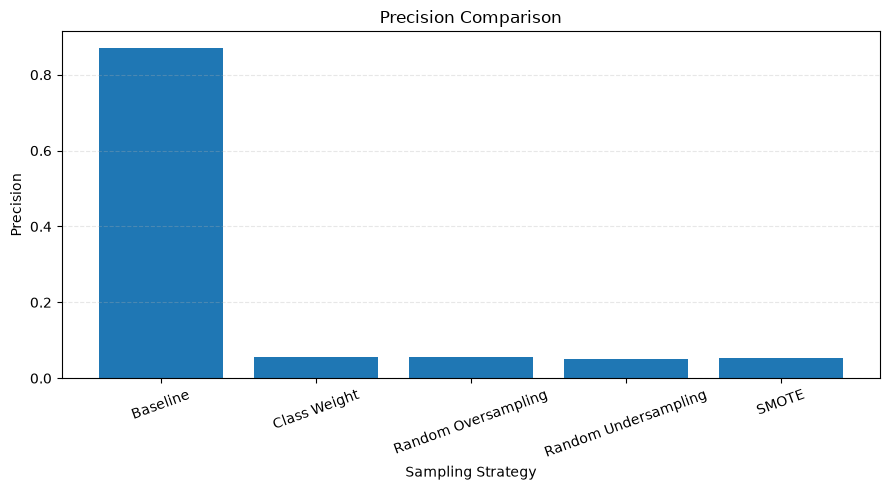

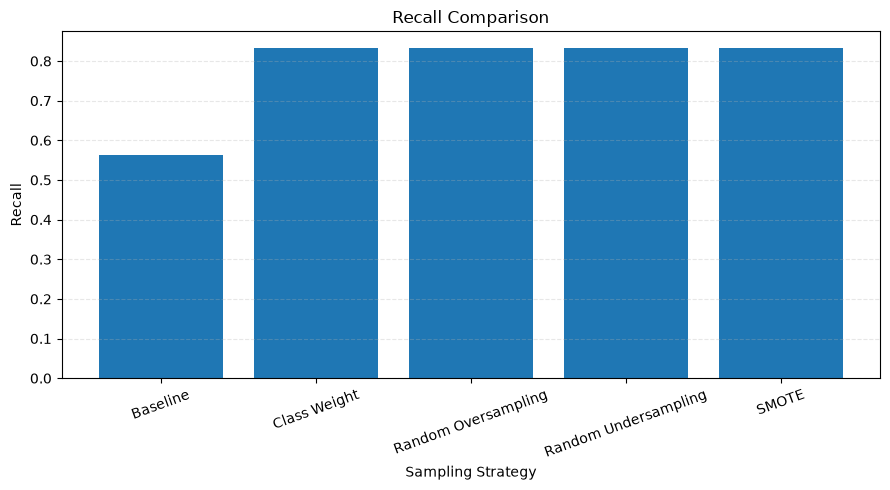

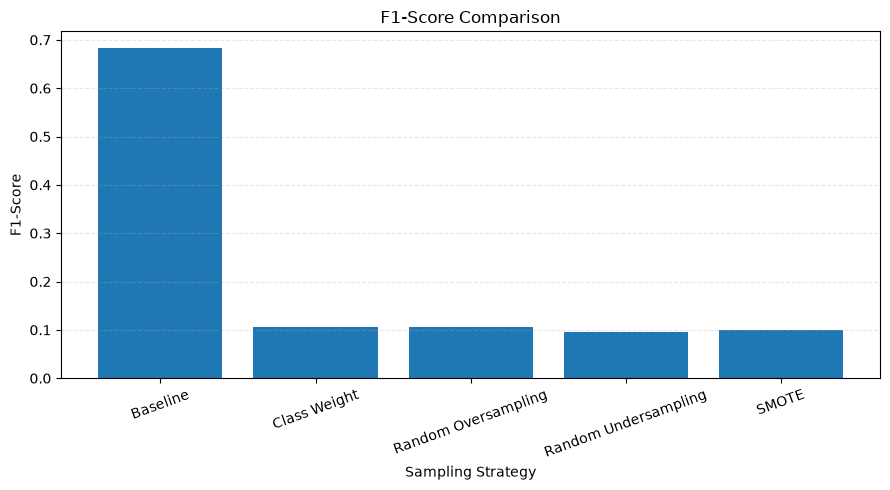

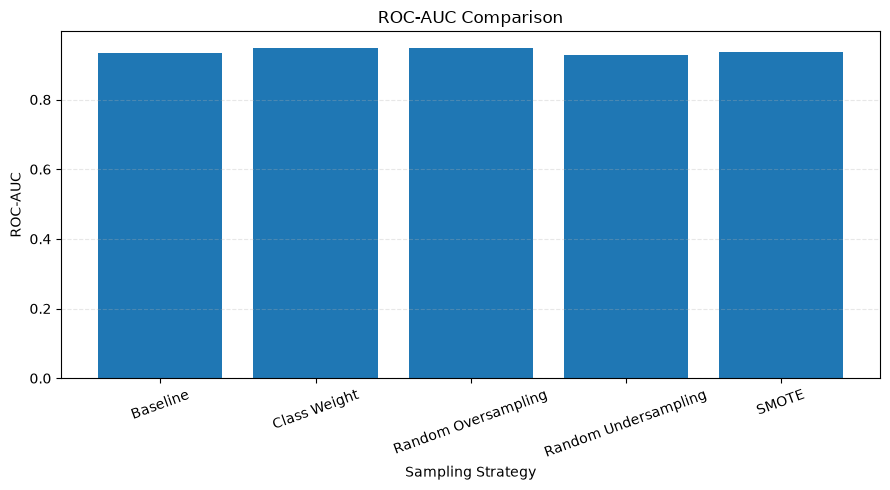

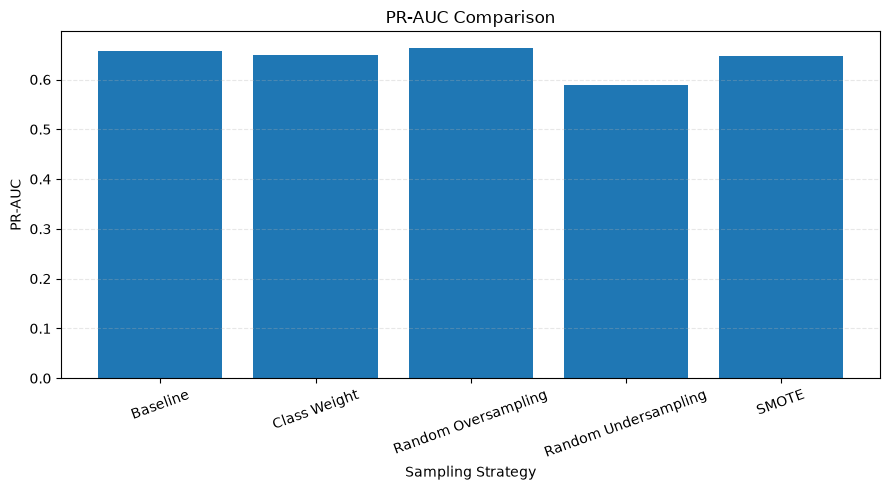

In [105]:
import matplotlib.pyplot as plt

metrics = [
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
]

strategy_columns = [
    "Baseline",
    "Class Weight",
    "Random Oversampling",
    "Random Undersampling",
    "SMOTE",
]

for metric in metrics:

    metric_values = comparison_table.loc[
        comparison_table["Metric"] == metric,
        strategy_columns
    ].T

    # Rename single column
    metric_values.columns = [metric]

    plt.figure(figsize=(9, 5))

    plt.bar(
        metric_values.index,
        metric_values[metric]
    )

    plt.title(f"{metric} Comparison")
    plt.xlabel("Sampling Strategy")
    plt.ylabel(metric)
    
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.xticks(rotation=20)

    plt.tight_layout()

    plt.show()

# 3.2.8 Select Final Sampling Strategy

After evaluating multiple imbalance handling techniques, the next step is to identify the most suitable sampling strategy for the remaining machine learning models.

The selection is based on overall model performance, business objectives, and the characteristics of fraud detection, where identifying fraudulent transactions is generally more important than maximizing overall Accuracy.

The selected strategy will be used consistently in the upcoming machine learning models to ensure a fair and standardized comparison throughout the project.

In [106]:
final_sampling_strategy = "SMOTE"

print("Selected Sampling Strategy :", final_sampling_strategy)

Selected Sampling Strategy : SMOTE


## 3.2.8.2 Justify Selection

Based on the comparative evaluation of all imbalance handling techniques, **SMOTE (Synthetic Minority Over-sampling Technique)** has been selected as the default sampling strategy for the subsequent machine learning models.

### Justification

- **High Fraud Detection Capability:** SMOTE achieved one of the highest Recall scores, allowing the model to identify a significantly larger proportion of fraudulent transactions than the Baseline model.

- **Strong Overall Performance:** In addition to improving Recall, SMOTE maintained competitive ROC-AUC and PR-AUC scores, demonstrating strong ranking performance on the minority class.

- **Synthetic Sample Generation:** Unlike Random Oversampling, which duplicates existing minority samples, SMOTE generates synthetic observations. This helps the model learn a more generalized decision boundary and reduces the risk of overfitting caused by repeated samples.

- **Balanced Trade-off:** Although Precision decreased compared to the Baseline model, the improvement in fraud detection outweighs the increase in false-positive predictions. This trade-off is acceptable because the business cost of missing fraudulent transactions is generally much higher than investigating additional legitimate transactions.

- **Scalability:** Selecting a single sampling strategy ensures that all upcoming machine learning models are trained under consistent conditions, enabling fair and unbiased performance comparisons.

### Final Decision

SMOTE will be used as the standard imbalance handling technique for all subsequent supervised machine learning models developed in this project unless a model-specific limitation or experimental result suggests a better alternative.

In [107]:
print("Sampling strategy justified successfully.")

Sampling strategy justified successfully.


## 3.2.8.3 Save Decision for Future Phases

To maintain consistency across the project, the selected imbalance handling strategy is stored as a reusable configuration.

This configuration will be referenced by all subsequent machine learning models, ensuring that every model is trained and evaluated using the same preprocessing pipeline.

Using a standardized sampling strategy enables fair model comparisons and improves the reproducibility of experimental results.

In [108]:
# Sampling strategy configuration for future models

MODEL_CONFIG = {
    "sampling_strategy": "SMOTE"
}

print("Model Configuration")
print(MODEL_CONFIG)

Model Configuration
{'sampling_strategy': 'SMOTE'}


## 3.2.8.4 Prepare Final Training Dataset

The SMOTE-balanced training dataset is selected as the standard training dataset for all subsequent machine learning models.

The testing dataset remains unchanged to ensure an unbiased evaluation of model performance. This follows the standard machine learning workflow where resampling techniques are applied only to the training data.

The finalized datasets prepared in this phase will be reused throughout the remaining supervised learning models in this project.

In [109]:
# Final datasets for future machine learning models

X_train_final = X_train_smote.copy()
y_train_final = y_train_smote.copy()

X_test_final = X_test_processed.copy()
y_test_final = y_test.copy()

print("Final Training Dataset Shape :", X_train_final.shape)
print("Final Training Labels Shape  :", y_train_final.shape)
print("Final Testing Dataset Shape  :", X_test_final.shape)
print("Final Testing Labels Shape   :", y_test_final.shape)

Final Training Dataset Shape : (453204, 33)
Final Training Labels Shape  : (453204,)
Final Testing Dataset Shape  : (28373, 33)
Final Testing Labels Shape   : (28373,)


# 3.2.9 Documentation Update

## Phase Summary

In this phase, multiple techniques were evaluated to address the class imbalance present in the fraud detection dataset.

The following imbalance handling strategies were implemented and compared:

- Baseline (No Sampling)
- Class Weight
- Random Oversampling
- Random Undersampling
- SMOTE (Synthetic Minority Over-sampling Technique)

Each strategy was evaluated using multiple performance metrics, including:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

A comparative analysis demonstrated that **SMOTE** provided the most balanced performance for fraud detection by substantially improving the model's ability to detect fraudulent transactions while maintaining strong overall classification performance.

Based on these results, SMOTE was selected as the standard sampling strategy for all subsequent supervised machine learning models in this project.

The finalized datasets (`X_train_final`, `y_train_final`, `X_test_final`, and `y_test_final`) will be reused throughout the remaining modeling phases to ensure consistency and fair model comparison.

In [110]:
print("=" * 60)
print("Phase 3.2 Completed Successfully")
print("=" * 60)

print("\nSummary")
print("- Evaluated 5 imbalance handling strategies")
print("- Compared 6 evaluation metrics")
print("- Selected SMOTE as the final sampling strategy")
print("- Prepared standardized training and testing datasets")
print("- Ready for Decision Tree modeling")

Phase 3.2 Completed Successfully

Summary
- Evaluated 5 imbalance handling strategies
- Compared 6 evaluation metrics
- Selected SMOTE as the final sampling strategy
- Prepared standardized training and testing datasets
- Ready for Decision Tree modeling


# 3.2.10 Export Final Datasets

To ensure reproducibility and notebook independence, the finalized training and testing datasets are exported to the project's `data/final/` directory.

These exported datasets will serve as the standardized input for all subsequent machine learning models. By saving the datasets once, future notebooks can load them directly without repeating the preprocessing pipeline.

The exported datasets include:

- X_train_final
- y_train_final
- X_test_final
- y_test_final

This approach improves maintainability, supports modular notebook design, and aligns with production-oriented machine learning workflows.

In [111]:
from pathlib import Path

import pandas as pd

# Create final data directory
final_data_dir = Path("../data/final")
final_data_dir.mkdir(parents=True, exist_ok=True)

# Convert target arrays to DataFrames if required
y_train_export = pd.DataFrame(y_train_final, columns=["Class"])
y_test_export = pd.DataFrame(y_test_final, columns=["Class"])

# Export datasets
X_train_final.to_csv(
    final_data_dir / "X_train_final.csv",
    index=False
)

y_train_export.to_csv(
    final_data_dir / "y_train_final.csv",
    index=False
)

X_test_final.to_csv(
    final_data_dir / "X_test_final.csv",
    index=False
)

y_test_export.to_csv(
    final_data_dir / "y_test_final.csv",
    index=False
)

print("Final datasets exported successfully.")
print(f"Export Location: {final_data_dir.resolve()}")

Final datasets exported successfully.
Export Location: F:\annuspeaks.com\fraud-detection-system\data\final


In [112]:
print(type(X_test))
print(type(X_test_processed))

print(X_test.columns[:5])

print(X_test_processed.columns[:5])

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
Index(['Time', 'V1', 'V2', 'V3', 'V4'], dtype='str')
Index(['scaler__Time', 'scaler__Amount', 'scaler__TransactionHour',
       'scaler__LogAmount', 'remainder__V1'],
      dtype='str')


In [113]:
print(X_train_final.columns.equals(X_test_processed.columns))

True


In [114]:
assert X_train_final.columns.equals(X_test_final.columns)

In [115]:
import joblib

pipeline = joblib.load("../artifacts/preprocessing_pipeline.pkl")

print(type(pipeline))
print(hasattr(pipeline, "steps"))
print(hasattr(pipeline, "feature_names_in_"))

from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(pipeline)
    print("✅ Pipeline is fitted")
except Exception as e:
    print(type(e).__name__)
    print(e)

<class 'sklearn.pipeline.Pipeline'>
True
True
✅ Pipeline is fitted
